In [ ]:
# %pip install scikit-image

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from skimage.feature import canny
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.draw import circle_perimeter
from skimage.segmentation import find_boundaries
from skimage.measure import find_contours

from scipy.optimize import least_squares

from scipy import ndimage
from scipy.ndimage import gaussian_filter
from scipy.ndimage import binary_fill_holes, binary_closing, binary_opening

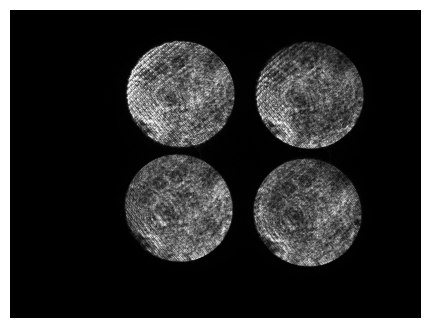

In [30]:
file = "data/2026-08-05/init_Xn1d221_Yp0d153_2026-08-05T11-36-15.633.tif"
# file = "data/2026-08-05/T_series_x_Xn1d221_Yn0d000_2026-08-05T11-43-31.269.tif"

image = mpimg.imread(file)
image = np.flipud(image) # Flip vertically

plt.figure(figsize=(6, 4))
plt.imshow(image, origin="lower", cmap="gray")
# plt.axhline(585, color="cyan")
plt.axis("off")
plt.show()

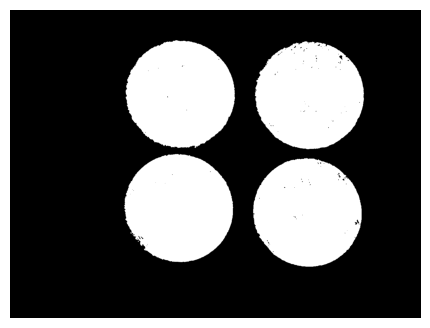

In [34]:
# Normalize image
img = image.astype(float)
img -= img.min()
img /= img.max()

# img[:585, :] = 0
img = gaussian_filter(img, sigma=1)

threshold = 0.08
mask = img > threshold

plt.figure(figsize=(6, 4))
plt.imshow(mask, origin="lower", cmap="gray")
# plt.axhline(585, color="cyan")
plt.axis("off")
plt.show()

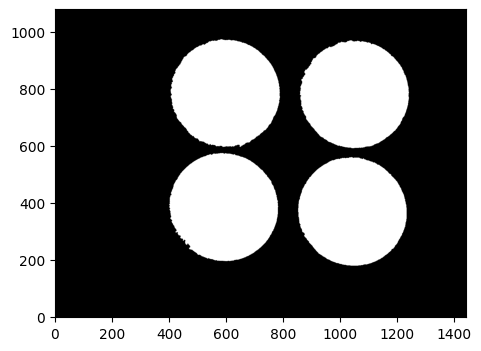

In [35]:
mask = binary_fill_holes(mask)
mask = binary_closing(mask, iterations=2)

plt.figure(figsize=(6, 4))
plt.imshow(mask, cmap="gray", origin="lower")
plt.show()

Pupil 1: (596.6, 784.4), r = 189.1
Pupil 2: (1049.4, 780.0), r = 188.8
Pupil 3: (591.5, 385.3), r = 188.9
Pupil 4: (1041.9, 369.2), r = 189.7


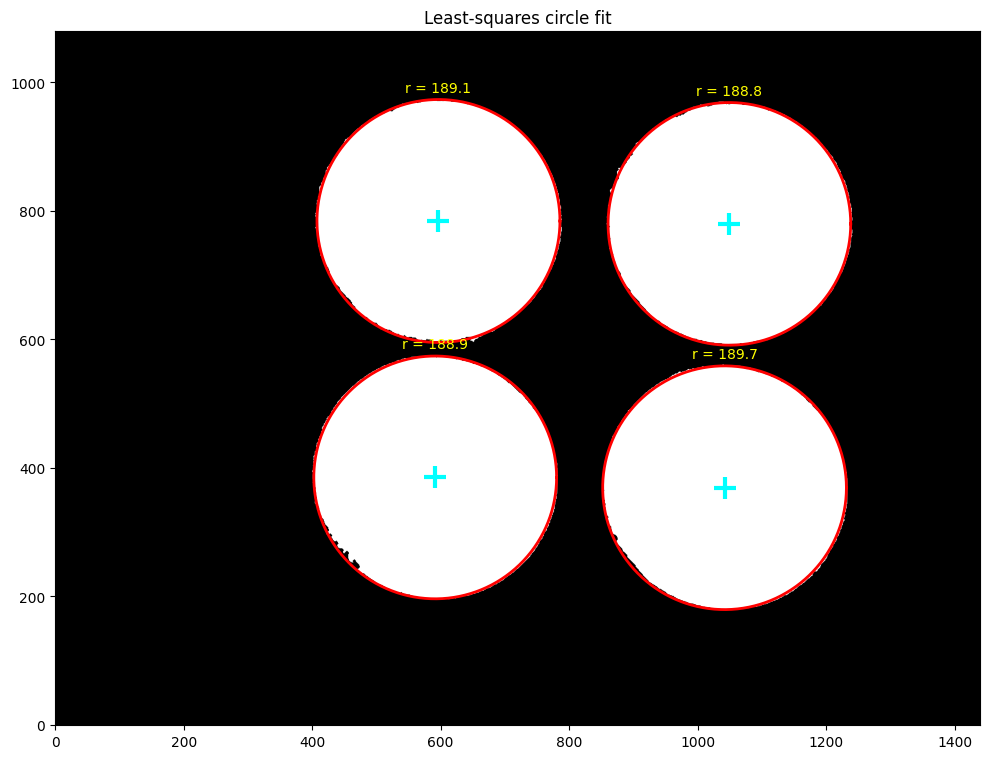

In [39]:
def fit_circle(x, y):
    """
    Least-squares fit of a circle to points (x, y).
    """

    def residuals(params):
        xc, yc, r = params
        return np.sqrt((x - xc)**2 + (y - yc)**2) - r

    x0 = x.mean()
    y0 = y.mean()
    r0 = np.mean(np.sqrt((x - x0)**2 + (y - y0)**2))

    result = least_squares(
        residuals,
        [x0, y0, r0],
    )

    return result.x


# ---------------------------------------------------------
# Label the pupils
# ---------------------------------------------------------

labels, nlabels = ndimage.label(mask)

circles = []

for label in range(1, nlabels + 1):

    region = labels == label

    # Ignore tiny blobs
    if region.sum() < 10000:
        continue

    contours = find_contours(region.astype(float), 0.5)

    contour = max(contours, key=len)

    y = contour[:, 0]
    x = contour[:, 1]

    xc, yc, r = fit_circle(x, y)

    circles.append((xc, yc, r))

# Sort top-to-bottom, then left-to-right
circles.sort(key=lambda c: (-c[1], c[0]))

for i, (xc, yc, r) in enumerate(circles, start=1):
    print(f"Pupil {i}: ({xc:.1f}, {yc:.1f}), r = {r:.1f}")
    
# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(mask, cmap="gray", origin="lower")

theta = np.linspace(0, 2*np.pi, 400)

for xc, yc, r in circles:

    ax.plot(
        xc + r*np.cos(theta),
        yc + r*np.sin(theta),
        color="red",
        linewidth=2,
    )

    ax.plot(
        xc,
        yc,
        "+",
        color="cyan",
        markersize=16,
        markeredgewidth=3,
    )

    ax.text(
        xc,
        yc + r + 12,
        f"r = {r:.1f}",
        color="yellow",
        ha="center",
    )

plt.title("Least-squares circle fit")
plt.tight_layout()
plt.show()